# Programming assignment 3: Recurrent Neural Networks and Transformer Encoder

## Overview

<font size='4'>In this assignment you will practice putting together implementations of Recurrent Neural Networks, Transformer Encoder, and their applications to text classification. Especially for Transformer, you will get good understandings about foundations for very state-of-the-art models that you likely to see in tech news articles nowadays, like ChatGPT.</font>

## Submission format

- <font size='4'>`<your_nu_username>_pa3.ipynb` with your implementations and output.</font>

## Setup

In [1]:
# data preparation

import re
import csv
import io
import urllib.request
from collections import Counter

_patterns = [
    r'\'',       # add spaces around apostrophes
    r'\"',       # remove double quotes
    r'\.',       # add spaces around periods
    r'<br \/>',  # replace HTML line breaks with space
    r',',        # add spaces around commas
    r'\(',       # add spaces around left parens
    r'\)',       # add spaces around right parens
    r'\!',       # add spaces around exclamation marks
    r'\?',       # add spaces around question marks
    r'\;',       # replace semicolons with space
    r'\:',       # replace colons with space
    r'\s+',      # collapse multiple whitespace into one
]
_replacements = [
    " ' ", '', ' . ', ' ', ' , ', ' ( ', ' ) ', ' ! ', ' ? ', ' ', ' ', ' ',
]
_pattern_pairs = [(re.compile(p), r) for p, r in zip(_patterns, _replacements)]

def tokenizer(line):
    """
    Basic English tokenizer. Lowercases the input, normalizes punctuation,
    and splits on whitespace. Produces identical output to
    torchtext.data.utils.get_tokenizer('basic_english').

    Example:
    >>> tokenizer("You can now install TorchText using pip!")
    ['you', 'can', 'now', 'install', 'torchtext', 'using', 'pip', '!']
    """
    line = line.lower()
    for pattern_re, replacement in _pattern_pairs:
        line = pattern_re.sub(replacement, line)
    return line.split()

_AG_NEWS_URLS = {
    'train': 'https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv',
    'test':  'https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/test.csv',
}

def load_ag_news(split='train'):
    """
    Download and return the AG News dataset as a list of (label, text) tuples.

    Args:
        split: 'train' (120,000 samples) or 'test' (7,600 samples)

    Returns:
        List of (int, str) tuples where label is 1-4 and text is the
        concatenation of the title and description fields.

    Example:
        >>> train_data = load_ag_news('train')
        >>> print(len(train_data))
        120000
        >>> print(train_data[0])
        (3, "Wall St. Bears Claw Back Into the Black ...")
    """
    assert split in _AG_NEWS_URLS, f"split must be 'train' or 'test', got '{split}'"
    url = _AG_NEWS_URLS[split]
    response = urllib.request.urlopen(url)
    reader = csv.reader(io.TextIOWrapper(response, encoding='utf-8'))
    data = [(int(row[0]), " ".join(row[1:])) for row in reader]
    return data

class Vocab:
    """
    A simple vocabulary that maps tokens to integer indices.
    Drop-in replacement for torchtext.vocab.Vocab.
    """

    def __init__(self, token_to_index):
        self.token_to_index = token_to_index
        self.default_index = 0

    def set_default_index(self, index):
        self.default_index = index

    def __getitem__(self, token):
        return self.token_to_index.get(token, self.default_index)

    def __len__(self):
        return len(self.token_to_index)

    def __call__(self, tokens):
        """Convert a list of tokens to a list of indices."""
        return [self.token_to_index.get(t, self.default_index) for t in tokens]


def build_vocab_from_iterator(iterator, specials=None):
    """
    Build a Vocab object from an iterator that yields lists of tokens.

    Args:
        iterator: An iterable where each element is a list of string tokens.
        specials: A list of special tokens (e.g., ["<unk>"]) to be placed at
                  the beginning of the vocabulary.

    Returns:
        A Vocab object.

    Example:
        >>> def yield_tokens(data):
        ...     for _, text in data:
        ...         yield tokenizer(text)
        >>> vocab = build_vocab_from_iterator(yield_tokens(train_data), specials=["<unk>"])
        >>> vocab.set_default_index(vocab["<unk>"])
        >>> vocab(["hello", "world"])
        [1234, 5678]
    """
    counter = Counter()
    for tokens in iterator:
        counter.update(tokens)

    specials = specials or []
    # Build ordered token list: specials first, then tokens by descending frequency
    itos = list(specials) + [tok for tok, _ in counter.most_common()]
    token_to_index = {tok: idx for idx, tok in enumerate(itos)}

    return Vocab(token_to_index)

def to_map_style_dataset(data_iter):
    """
    Convert an iterable dataset to a map-style dataset (a list).

    This is a drop-in replacement for torchtext.data.functional.to_map_style_dataset.
    Since load_ag_news() already returns a list, this function is provided only
    for compatibility with the existing notebook structure.

    Args:
        data_iter: Any iterable of data samples.

    Returns:
        A list containing all samples from the iterable.
    """
    return list(data_iter)

In [2]:
import math

import torch
import torch.nn as nn
import torch.nn.functional as F

train_data = load_ag_news('train')

# Let's check what the data looks like
print('There are {} training samples in the training set.'.format(len(list(train_data))))
# label, news content
print(next(iter(train_data)))

There are 120000 training samples in the training set.
(3, "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.")


## Part 1: Text Classification with RNN (32 points)

### <font size='4' color='red'>Task 1.1: Implement a RNNCell (6 points)</font>

In [3]:
# Documentation of nn.Module https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module
class RNNCell(torch.nn.Module):
    """
    RNNCell is a single cell that takes x_t and h_{t_1} as input and outputs h_t.
    """
    def __init__(self, input_dim: int, hidden_dim: int):
        """
        Constructor of RNNCell.

        Inputs:
        - input_dim: Dimension of the input x_t
        - hidden_dim: Dimension of the hidden state h_{t-1} and h_t
        """

        # We always need to do this step to properly implement the constructor
        super(RNNCell, self).__init__()

        self.linear_x, self.linear_h, self.non_linear = None, None, None

        ###########################################################################
        # TODO: Define the linear transformation layers for x_t and h_{t-1} and   #
        # the non-linear layer. You can use tanh here.                            #
        ###########################################################################
        
        self.linear_x = nn.Linear(input_dim, hidden_dim)
        self.linear_h = nn.Linear(hidden_dim, hidden_dim)
        self.non_linear = nn.Tanh()
        
        ###########################################################################
        #                             END OF YOUR CODE                            #
        ###########################################################################

    def forward(self, x_cur: torch.Tensor, h_prev: torch.Tensor):
        """
        Compute h_t given x_t and h_{t-1}.

        Inputs:
        - x_cur: x_t, a tensor with the same of BxC, where B is the batch size and
          C is the channel dimension.
        - h_prev: h_{t-1}, a tensor with the same of BxH, where H is the channel
          dimension.
        """
        h_cur = None
        ###########################################################################
        # TODO: Define the linear transformation layers for x_t and h_{t-1} and   #
        # the non-linear layer.                                                   #
        ###########################################################################
        
        h_cur = self.non_linear(self.linear_x(x_cur) + self.linear_h(h_prev))
        
        ###########################################################################
        #                             END OF YOUR CODE                            #
        ###########################################################################
        return h_cur

In [4]:
# Let's run a sanity check of your model
x = torch.randn((2, 8))
h = torch.randn((2, 16))
model = RNNCell(8, 16)
y = model(x, h)
assert len(y.shape) == 2 and y.shape[0] == 2 and y.shape[1] == 16
print(y.shape)

torch.Size([2, 16])


### <font size='4' color='red'>Task 1.2: Implement a single-layer (single-stack) RNN (6 points)</font>

In [5]:
class RNN(torch.nn.Module):
    """
    RNN is a single-layer (stack) RNN by connecting multiple RNNCell together in a single
    direction, where the input sequence is processed from left to right.
    """
    def __init__(self, input_dim: int, hidden_dim: int):
        """
        Constructor of the RNN module.

        Inputs:
        - input_dim: Dimension of the input x_t
        - hidden_dim: Dimension of the hidden state h_{t-1} and h_t
        """
        super(RNN, self).__init__()

        self.hidden_dim = hidden_dim

        ###########################################################################
        # TODO: Define the RNNCell.                                               #
        ###########################################################################
        
        self.cell = RNNCell(input_dim, hidden_dim)
        
        ###########################################################################
        #                             END OF YOUR CODE                            #
        ###########################################################################

    def forward(self, x: torch.Tensor):
        """
        Compute the hidden representations for every token in the input sequence.

        Input:
        - x: A tensor with the shape of BxLxC, where B is the batch size, L is the squence
          length, and C is the channel dimmension

        Return:
        - h: A tensor with the shape of BxLxH, where H is the hidden dimension of RNNCell
        """
        b = x.shape[0]
        seq_len = x.shape[1]

        # initialize the hidden dimension
        init_h = x.new_zeros((b, self.hidden_dim))

        h = None
        ###########################################################################
        # TODO: Compute the hidden representation for every token in the input    #
        # from left to right.
        ###########################################################################
        
        h_t = init_h
        h_list = []
        
        for t in range(seq_len):
            h_t = self.cell(x[:, t, :], h_t)
            h_list.append(h_t)
            
        h = torch.stack(h_list, dim=1)
        
        ###########################################################################
        #                             END OF YOUR CODE                            #
        ###########################################################################

        return h

In [6]:
# Let's run a sanity check of your model
x = torch.randn((2, 10, 8))
model = RNN(8, 16)
y = model(x)
assert len(y.shape) == 3
for dim, dim_gt in zip(y.shape, [2, 10, 16]):
    assert dim == dim_gt
print(y.shape)

torch.Size([2, 10, 16])


### <font size='4' color='red'>Task 1.3: Implement a RNN-based text classifier (6 points)</font>

In [7]:
class RNNClassifier(nn.Module):
    """
    A RNN-based classifier for text classification. It first converts tokens into word embeddings.
    And then feeds the embeddings into a RNN, where the hidden representations of all tokens are
    then averaged to get a single embedding of the sentence. It will be used as input to a linear
    classifier.
    """
    def __init__(self,
            vocab_size: int, embed_dim: int, rnn_hidden_dim: int, num_class: int, pad_token: int
        ):
        """
        Constructor.

        Inputs:
        - vocab_size: Vocabulary size, indicating how many tokens we have in total.
        - embed_dim: The dimension of word embeddings
        - rnn_hidden_dim: The hidden dimension of the RNN.
        - num_class: Number of classes.
        - pad_token: The index of the padding token.
        """
        super(RNNClassifier, self).__init__()

        # word embedding layer
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_token)

        self.rnn, self.fc = None, None

        ###########################################################################
        # TODO: Define the RNN and the classification layer.                      #
        ###########################################################################
        
        self.rnn = RNN(embed_dim, rnn_hidden_dim)
        self.fc = nn.Linear(rnn_hidden_dim, num_class)
        
        ###########################################################################
        #                             END OF YOUR CODE                            #
        ###########################################################################

    def init_weights(self):
        initrange = 0.5
        self.embedding.weight.data.uniform_(-initrange, initrange)
        self.fc.weight.data.uniform_(-initrange, initrange)
        self.fc.bias.data.zero_()

    def forward(self, text):
        """
        Get classification scores (logits) of the input.

        Input:
        - text: Tensor with the shape of BxLxC.

        Return:
        - logits: Tensor with the shape of BxK, where K is the number of classes
        """

        # get word embeddings
        embedded = self.embedding(text)

        logits = None
        ###########################################################################
        # TODO: Compute logits of the input.                                      #
        ###########################################################################
        
        h = self.rnn(embedded)
        h_mean = h.mean(dim=1)
        logits = self.fc(h_mean)
        
        ###########################################################################
        #                             END OF YOUR CODE                            #
        ###########################################################################

        return logits

In [8]:
# Let's run a sanity check of your model
vocab_size = 10
embed_dim = 16
rnn_hidden_dim = 32
num_class = 3

x = torch.arange(vocab_size).view(1, -1)
x = torch.cat((x, x), dim=0)
print('x.shape: {}'.format(x.shape))
model = RNNClassifier(vocab_size, embed_dim, rnn_hidden_dim, num_class, 0)
y = model(x)
assert len(y.shape) == 2 and y.shape[0] == 2 and y.shape[1] == num_class
print(y.shape)

model = model.to('cuda:0')
x = x.to('cuda:0')
y = model(x)
print(y.shape, y.device)

x.shape: torch.Size([2, 10])
torch.Size([2, 3])
torch.Size([2, 3]) cuda:0


### Set up data related stuff

In [9]:
train_iter = load_ag_news(split='train')

def yield_tokens(data_iter):
    for _, text in data_iter:
        yield tokenizer(text)

# Creates a vocab object which maps tokens to indices
# Check here for details https://github.com/pytorch/text/blob/main/torchtext/vocab/vocab.py
vocab = build_vocab_from_iterator(yield_tokens(train_iter), specials=["<unk>"])

# The specified token will be returned when a out-of-vocabulary token is queried.
vocab.set_default_index(vocab["<unk>"])

text_pipeline = lambda x: vocab(tokenizer(x))
label_pipeline = lambda x: int(x) - 1

# The padding token we need to use
# The returned indices are always in an array
PAD_TOKEN = vocab(tokenizer('<pad>'))
assert len(PAD_TOKEN) == 1
PAD_TOKEN = PAD_TOKEN[0]

### <font size='4' color='red'>Task 1.4: Collate Batched Data with Data Loaders (5 points)</font>

In [10]:
# Documentation of DataLoader https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader
from torch.utils.data import DataLoader

# Merges a list of samples to form a mini-batch of Tensor(s)
def collate_batch(batch):
    """
    Input:
    - batch: A list of data in a mini batch, where the length denotes the batch size.
      The actual context depends on a particular dataset. In our case, each position
      contains a label and a Tensor (tokens in a sentence).

    Returns:
    - batched_label: A Tensor with the shape of (B,)
    - batched_text: A Tensor with the shape of (B, L, C), where L is the sequence length
      and C is the channel dimension
    """
    label_list, text_list, text_len_list = [], [], []
    for (_label, _text) in batch:
        label_list.append(label_pipeline(_label))
        processed_text = torch.tensor(text_pipeline(_text), dtype=torch.int64)
        text_list.append(processed_text)
        text_len_list.append(processed_text.size(0))
    batched_label, batched_text = None, None
    ###########################################################################
    # TODO: Pad the text tensor in the mini batch so that they have the same  #
    # length. Specifically, you need to calculate the maximum length in the   #
    # batch and then add the token PAD_TOKEN to the end of those              #
    # shorter sentences.                                                      #
    ###########################################################################
    
    max_len = max(text_len_list)
    padded = []
    
    for text in text_list:
        pad_len = max_len - text.size(0)
        
        if pad_len > 0:
            padding = torch.full((pad_len,), PAD_TOKEN, dtype=torch.int64)
            text = torch.cat([text, padding])
            
        padded.append(text)
        
    batched_label = torch.tensor(label_list, dtype=torch.int64)
    batched_text = torch.stack(padded, dim=0)
    
    ###########################################################################
    #                             END OF YOUR CODE                            #
    ###########################################################################

    return batched_label.long(), batched_text.long()

# Now, let's check what the batched data looks like
train_iter = load_ag_news(split='train')
dataloader = DataLoader(train_iter, batch_size=8, shuffle=False, collate_fn=collate_batch)
for idx, (label, data) in enumerate(dataloader):
    if idx > 0:
        break
    print('label.shape: {}'.format(label.shape))
    print('label: {}'.format(label))
    print('data.shape: {}'.format(data.shape))

label.shape: torch.Size([8])
label: tensor([2, 2, 2, 2, 2, 2, 2, 2])
data.shape: torch.Size([8, 49])


### <font size='4' color='red'>Task 1.5: Functions of training for a single epoch and evaluation (5 points)</font>

In [11]:
import time

def train(model, dataloader, loss_func, device, grad_norm_clip):
    model.train()
    total_acc, total_count = 0, 0
    log_interval = 500
    start_time = time.time()

    for idx, (label, text) in enumerate(dataloader):
        label = label.to(device)
        text = text.to(device)
        optimizer.zero_grad()

        logits = None
        ###########################################################################
        # TODO: compute the logits of the input, get the loss, and do the         #
        # gradient backpropagation.
        ###########################################################################
        
        logits = model(text)
        loss = loss_func(logits, label)
        loss.backward()
        
        ###########################################################################
        #                             END OF YOUR CODE                            #
        ###########################################################################

        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_norm_clip)
        optimizer.step()
        total_acc += (logits.argmax(1) == label).sum().item()
        total_count += label.size(0)
        if idx % log_interval == 0 and idx > 0:
            elapsed = time.time() - start_time
            print('| epoch {:3d} | {:5d}/{:5d} batches '
                  '| accuracy {:8.3f}'.format(epoch, idx, len(dataloader),
                                              total_acc/total_count))
            total_acc, total_count = 0, 0
            start_time = time.time()

def evaluate(model, dataloader, loss_func, device):
    model.eval()
    total_acc, total_count = 0, 0

    with torch.no_grad():
        for idx, (label, text) in enumerate(dataloader):
            label = label.to(device)
            text = text.to(device)

            ###########################################################################
            # TODO: compute the logits of the input, get the loss.                    #
            ###########################################################################
            
            logits = model(text)
            loss = loss_func(logits, label)
            
            ###########################################################################
            #                             END OF YOUR CODE                            #
            ###########################################################################

            total_acc += (logits.argmax(1) == label).sum().item()
            total_count += label.size(0)
    return total_acc/total_count

### <font size='4' color='red'>Task 1.6: Define the model, loss function, optimizer, and learning rate scheduler. You do not have to tune the hyperparameters here (our implementation is not optimal and thus slow). You should achieve 87% validation accuracy. (4 points)</font>

In [12]:
from torch.utils.data.dataset import random_split
# from torchtext.data.functional import to_map_style_dataset

assert torch.cuda.is_available()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# hyper parameters
epochs = 3 # epoch
lr = 0.0005 # learning rate
batch_size = 64 # batch size for training
word_embed_dim = 64
rnn_hidden_dim = 96


train_iter = load_ag_news(split='train')
num_class = len(set([label for (label, text) in train_iter]))
vocab_size = len(vocab)

model, loss_func = None, None
###########################################################################
# TODO: Deinfe the classifier, loss function, optimizer, and lr_scheduler.
# You are encouraged to use the AdamW optimizer and find a suitable       #
# learning rate scheduler for it.                                         #
###########################################################################

model = RNNClassifier(vocab_size, word_embed_dim, rnn_hidden_dim, num_class, PAD_TOKEN)
model.init_weights()

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.1)

###########################################################################
#                             END OF YOUR CODE                            #
###########################################################################

# copy the model to the specified device (GPU)
model = model.to(device)

num_params = sum(p.numel() for p in model.parameters())
print('Number of parameters: {:.3f}K'.format(num_params / 1000))

total_accu = None
train_iter, test_iter = load_ag_news('train'), load_ag_news('test')
train_dataset = to_map_style_dataset(train_iter)
test_dataset = to_map_style_dataset(test_iter)
num_train = int(len(train_dataset) * 0.95)
split_train, split_valid = random_split(
    train_dataset,
    [num_train, len(train_dataset) - num_train]
)

train_dataloader = DataLoader(
    split_train, batch_size=batch_size,
    shuffle=True, collate_fn=collate_batch
)

valid_dataloader = DataLoader(
    split_valid, batch_size=batch_size,
    shuffle=False, collate_fn=collate_batch
)

test_dataloader = DataLoader(
    test_dataset, batch_size=batch_size,
    shuffle=False, collate_fn=collate_batch
)

# You should be able get a validation accuracy around 87%
for epoch in range(1, epochs + 1):
    epoch_start_time = time.time()
    train(model, train_dataloader, loss_func, device, 1)
    accu_val = evaluate(model, valid_dataloader, loss_func, device)
    if total_accu is not None and total_accu > accu_val:
        scheduler.step()
    else:
        total_accu = accu_val
    print('-' * 59)
    print('| end of epoch {:3d} | time: {:5.2f}s | '
          'valid accuracy {:8.3f} '.format(epoch,
                                           time.time() - epoch_start_time,
                                           accu_val))
    print('-' * 59)

cuda
Number of parameters: 6147.844K
| epoch   1 |   500/ 1782 batches | accuracy    0.542
| epoch   1 |  1000/ 1782 batches | accuracy    0.727
| epoch   1 |  1500/ 1782 batches | accuracy    0.829
-----------------------------------------------------------
| end of epoch   1 | time: 65.51s | valid accuracy    0.880 
-----------------------------------------------------------
| epoch   2 |   500/ 1782 batches | accuracy    0.887
| epoch   2 |  1000/ 1782 batches | accuracy    0.896
| epoch   2 |  1500/ 1782 batches | accuracy    0.901
-----------------------------------------------------------
| end of epoch   2 | time: 65.28s | valid accuracy    0.884 
-----------------------------------------------------------
| epoch   3 |   500/ 1782 batches | accuracy    0.922
| epoch   3 |  1000/ 1782 batches | accuracy    0.926
| epoch   3 |  1500/ 1782 batches | accuracy    0.925
-----------------------------------------------------------
| end of epoch   3 | time: 65.11s | valid accuracy    0

## Part 2: Text Classification with Transformer Encoder (68 points)

### <font size='4' color='red'>Task 2.1: Implement the multi-head attention module. No for are loops allowed. (15 points)</font>

In [13]:
class MultiHeadAttention(nn.Module):
    """
    A module that computes multi-head attention given query, key, and value tensors.
    """
    def __init__(self, input_dim: int, num_heads: int):
        """
        Constructor.

        Inputs:
        - input_dim: Dimension of the input query, key, and value. Here we assume they all have
          the same dimensions. But they could have different dimensions in other problems.
        - num_heads: Number of attention heads
        """
        super(MultiHeadAttention, self).__init__()

        assert input_dim % num_heads == 0

        self.input_dim = input_dim
        self.num_heads = num_heads
        # channel dimension per attention head
        self.dim_per_head = input_dim // num_heads

        ###########################################################################
        # TODO: Define the linear transformation layers for key, value, and query.#
        # Also define the output layer.
        ###########################################################################
        
        self.W_q = nn.Linear(input_dim, input_dim)
        self.W_k = nn.Linear(input_dim, input_dim)
        self.W_v = nn.Linear(input_dim, input_dim)
        
        self.W_o = nn.Linear(input_dim, input_dim)
        
        ###########################################################################
        #                             END OF YOUR CODE                            #
        ###########################################################################


    def forward(self, query: torch.Tensor, key: torch.Tensor, value: torch.Tensor, mask: torch.Tensor=None):
        """
        Compute the attended feature representations.

        Inputs:
        - query: Tensor of the shape BxLxC, where B is the batch size, L is the sequence length,
          and C is the channel dimension
        - key: Tensor of the shape BxLxC
        - value: Tensor of the shape BxLxC
        - mask: Tensor indicating where the attention should *not* be performed
        """
        b = query.shape[0]

        dot_prod_scores = None
        ###########################################################################
        # TODO: Compute the scores based on dot product between transformed query,#
        # key, and value. You may find torch.matmul helpful, whose documentation  #
        # can be found at                                                         #
        # https://pytorch.org/docs/stable/generated/torch.matmul.html#torch.matmul#
        # Remember to divide the dot product similarity scores by square root of  #
        # the channel dimension per head.
        #                                                                         #
        # Since no for loops are allowed here, think of how to use tensor reshape #
        # to process multiple attention heads at the same time.                   #
        ###########################################################################
        
        Q = self.W_q(query).view(b, -1, self.num_heads, self.dim_per_head).transpose(1, 2)
        K = self.W_k(key).view(b, -1, self.num_heads, self.dim_per_head).transpose(1, 2)
        V = self.W_v(value).view(b, -1, self.num_heads, self.dim_per_head).transpose(1, 2)

        dot_prod_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.dim_per_head)
        
        ###########################################################################
        #                             END OF YOUR CODE                            #
        ###########################################################################

        if mask is not None:
            # We simply set the similarity scores to be near negative infinity for
            # the positions where the attention should not be done. Think of why  #
            # we do this.
            dot_prod_scores = dot_prod_scores.masked_fill(mask == 0, -1e9)

        out = None
        ###########################################################################
        # TODO: Compute the attention scores, which are then used to modulate the #
        # value tensor. Finally concatenate the attended tensors from multiple    #
        # heads and feed it into the output layer. You may still find             #
        # torch.matmul helpful.                                                   #
        #                                                                         #
        # Again, think of how to use reshaping tensor to do the concatenation.    #
        ###########################################################################
        
        attn = F.softmax(dot_prod_scores, dim=-1)
        attended = torch.matmul(attn, V)
        
        attended = attended.transpose(1, 2).contiguous().view(b, -1, self.input_dim)
        out = self.W_o(attended)
        
        ###########################################################################
        #                             END OF YOUR CODE                            #
        ###########################################################################

        return out

In [14]:
x = torch.randn((2, 10, 8))
mask = torch.randn((2, 10)) > 0.5
mask = mask.unsqueeze(1).unsqueeze(-1)
num_heads = 4
model = MultiHeadAttention(8, num_heads)
y = model(x, x, x, mask)
assert len(y.shape) == len(x.shape)
for dim_x, dim_y in zip(x.shape, y.shape):
    assert dim_x == dim_y
print(y.shape)

torch.Size([2, 10, 8])


### <font size='4' color='red'>Task 2.2: Implement a Feedforward Network (4 points)</font>

In [15]:
class FeedForwardNetwork(nn.Module):
    """
    A simple feedforward network. Essentially, it is a two-layer fully-connected
    neural network.
    """
    def __init__(self, input_dim, ff_dim, dropout):
        """
        Inputs:
        - input_dim: Input dimension
        - ff_dim: Hidden dimension
        """
        super(FeedForwardNetwork, self).__init__()

        ###########################################################################
        # TODO: Define the two linear layers and a non-linear one.                #
        ###########################################################################
        
        self.fc1 = nn.Linear(input_dim, ff_dim)
        self.fc2 = nn.Linear(ff_dim, input_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        
        ###########################################################################
        #                             END OF YOUR CODE                            #
        ###########################################################################

    def forward(self, x: torch.Tensor):
        """
        Input:
        - x: Tensor of the shape BxLxC, where B is the batch size, L is the sequence length,
         and C is the channel dimension

        Return:
        - y: Tensor of the shape BxLxC
        """

        y = None
        ###########################################################################
        # TODO: Process the input.                                                #
        ###########################################################################
        
        y = self.fc2(self.dropout(self.relu(self.fc1(x))))
        
        ###########################################################################
        #                             END OF YOUR CODE                            #
        ###########################################################################

        return y

In [16]:
x = torch.randn((2, 10, 8))
ff_dim = 4
model = FeedForwardNetwork(8, ff_dim, 0.1)
y = model(x)
assert len(x.shape) == len(y.shape)
for dim_x, dim_y in zip(x.shape, y.shape):
    assert dim_x == dim_y
print(y.shape)

torch.Size([2, 10, 8])


### <font size='4' color='red'>Task 2.3: Implement a single Transformer Encoder Cell using post layer normalization (15 points)</font>

In [17]:
class TransformerEncoderCell(nn.Module):
    """
    A single cell (unit) for the Transformer encoder.
    """
    def __init__(self, input_dim: int, num_heads: int, ff_dim: int, dropout: float):
        """
        Inputs:
        - input_dim: Input dimension for each token in a sequence
        - num_heads: Number of attention heads in a multi-head attention module
        - ff_dim: The hidden dimension for a feedforward network
        - dropout: Dropout ratio for the output of the multi-head attention and feedforward
          modules.
        """
        super(TransformerEncoderCell, self).__init__()

        ###########################################################################
        # TODO: A single Transformer encoder cell consists of
        # 1. A multi-head attention module
        # 2. Followed by dropout
        # 3. Followed by layer norm (check nn.LayerNorm)
        # https://pytorch.org/docs/stable/generated/torch.nn.LayerNorm.html#torch.nn.LayerNorm

        # At the same time, it also has
        # 1. A feedforward network
        # 2. Followed by dropout
        # 3. Followed by layer norm
        ###########################################################################
        
        self.attention = MultiHeadAttention(input_dim, num_heads)
        self.dropout1 = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(input_dim)

        self.ffn = FeedForwardNetwork(input_dim, ff_dim, dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(input_dim)
        
        ###########################################################################
        #                             END OF YOUR CODE                            #
        ###########################################################################

    def forward(self, x: torch.Tensor, mask: torch.Tensor=None):
        """
        Inputs:
        - x: Tensor of the shape BxLxC, where B is the batch size, L is the sequence length,
          and C is the channel dimension
        - mask: Tensor for masking in the multi-head attention
        """

        y = None
        ###########################################################################
        # TODO: Get the output of the multi-head attention part (with dropout     #
        # and layer norm), which is used as input to the feedforward network (    #
        # again, followed by dropout and layer norm).                             #
        #                                                                         #
        # Don't forget the residual connections for both parts.                   #
        ###########################################################################
        
        attn_out = self.attention(x, x, x, mask)
        x = self.norm1(x + self.dropout1(attn_out))
        
        ffn_out = self.ffn(x)
        y = self.norm2(x + self.dropout2(ffn_out))
        
        ###########################################################################
        #                             END OF YOUR CODE                            #
        ###########################################################################

        return y

In [18]:
x = torch.randn((2, 10, 8))
mask = torch.randn((2, 10)) > 0.5
mask = mask.unsqueeze(1).unsqueeze(-1)
num_heads = 4
model = TransformerEncoderCell(8, num_heads, 32, 0.1)
y = model(x, mask)
assert len(x.shape) == len(y.shape)
for dim_x, dim_y in zip(x.shape, y.shape):
    assert dim_x == dim_y
print(y.shape)

torch.Size([2, 10, 8])


### <font size='4' color='red'>Task 2.4: Implement Transformer Encoder (8 points)</font>

In [19]:
class TransformerEncoder(nn.Module):
    """
    A full encoder consisting of a set of TransformerEncoderCell.
    """
    def __init__(self, input_dim: int, num_heads: int, ff_dim: int, num_cells: int, dropout: float=0.1):
        """
        Inputs:
        - input_dim: Input dimension for each token in a sequence
        - num_heads: Number of attention heads in a multi-head attention module
        - ff_dim: The hidden dimension for a feedforward network
        - num_cells: Number of TransformerEncoderCells
        - dropout: Dropout ratio for the output of the multi-head attention and feedforward
          modules.
        """
        super(TransformerEncoder, self).__init__()

        self.norm = None
        ###########################################################################
        # TODO: Construct a nn.ModuleList to store a stack of                     #
        # TranformerEncoderCells. Check the documentation here of how to use it   #
        # https://pytorch.org/docs/stable/generated/torch.nn.ModuleList.html#torch.nn.ModuleList

        # At the same time, define a layer normalization layer to process the     #
        # output of the entire encoder.                                           #
        ###########################################################################
        
        self.cells = nn.ModuleList([
            TransformerEncoderCell(input_dim, num_heads, ff_dim, dropout)
            for _ in range(num_cells)
        ])
        self.norm = nn.LayerNorm(input_dim)
        
        ###########################################################################
        #                             END OF YOUR CODE                            #
        ###########################################################################

    def forward(self, x: torch.Tensor, mask: torch.Tensor=None):
        """
        Inputs:
        - x: Tensor of the shape BxLxC, where B is the batch size, L is the sequence length,
          and C is the channel dimension
        - mask: Tensor for masking in the multi-head attention

        Return:
        - y: Tensor of the shape of BxLxC, which is the normalized output of the encoder
        """

        y = None
        ###########################################################################
        # TODO: Feed x into the stack of TransformerEncoderCells and then         #
        # normalize the output with layer norm.                                   #
        ###########################################################################
        
        y = x
        for cell in self.cells:
            y = cell(y, mask)
        y = self.norm(y)
        
        ###########################################################################
        #                             END OF YOUR CODE                            #
        ###########################################################################

        return y

In [20]:
x = torch.randn((2, 10, 8))
mask = torch.randn((2, 10)) > 0.5
mask = mask.unsqueeze(1).unsqueeze(-1)
num_heads = 4
model = TransformerEncoder(8, num_heads, 32, 2, 0.1)
y = model(x)
assert len(x.shape) == len(y.shape)
for dim_x, dim_y in zip(x.shape, y.shape):
    assert dim_x == dim_y
print(y.shape)

torch.Size([2, 10, 8])


### <font size='4' color='red'>Task 2.5: Implement Positional Encoding (10 points)</font>

In [21]:
class PositionalEncoding(nn.Module):
    """
    A module that adds positional encoding to each of the token's features.
    So that the Transformer is position aware.
    """
    def __init__(self, input_dim: int, max_len: int=10000):
        """
        Inputs:
        - input_dim: Input dimension about the features for each token
        - max_len: The maximum sequence length
        """
        super(PositionalEncoding, self).__init__()

        self.input_dim = input_dim

    def forward(self, x, max_length=10000):
        """
        Compute the positional encoding and add it to x.

        Input:
        - x: Tensor of the shape BxLxC, where B is the batch size, L is the sequence length,
          and C is the channel dimension
        - max_length: maximum sequence length the positional encoding can handle

        Return:
        - x: Tensor of the shape BxLxC, with the positional encoding added to the input
        """
        seq_len = x.shape[1]
        input_dim = x.shape[2]

        pe = None
        ###########################################################################
        # TODO: Compute the positional encoding                                   #
        # Check Section 3.5 for the definition (https://arxiv.org/pdf/1706.03762.pdf)
        #                                                                         #
        # It's a bit messy, but the definition is provided for your here for your #
        # convenience (in LaTex).                                                 #
        # PE_{(pos,2i)} = sin(pos / 10000^{2i/\dmodel}) \\                        #
        # PE_{(pos,2i+1)} = cos(pos / 10000^{2i/\dmodel})                         #
        #                                                                         #
        # You should replace 10000 with max_len here.
        ###########################################################################
        
        positions = torch.arange(seq_len, dtype=torch.float).unsqueeze(1)
        dims = torch.arange(0, input_dim, 2, dtype=torch.float)
        div_term = torch.pow(torch.tensor(max_length, dtype=torch.float), dims / input_dim)

        pe = torch.zeros(seq_len, input_dim)
        pe[:, 0::2] = torch.sin(positions / div_term)
        pe[:, 1::2] = torch.cos(positions / div_term)
        pe = pe.unsqueeze(0)
        
        ###########################################################################
        #                             END OF YOUR CODE                            #
        ###########################################################################

        x = x + pe.to(x.device)
        return x

In [22]:
# Sanity check
x = torch.randn(1, 100, 20)
pe = PositionalEncoding(20)
y = pe(x)
assert len(x.shape) == len(y.shape)
for dim_x, dim_y in zip(x.shape, y.shape):
    assert dim_x == dim_y

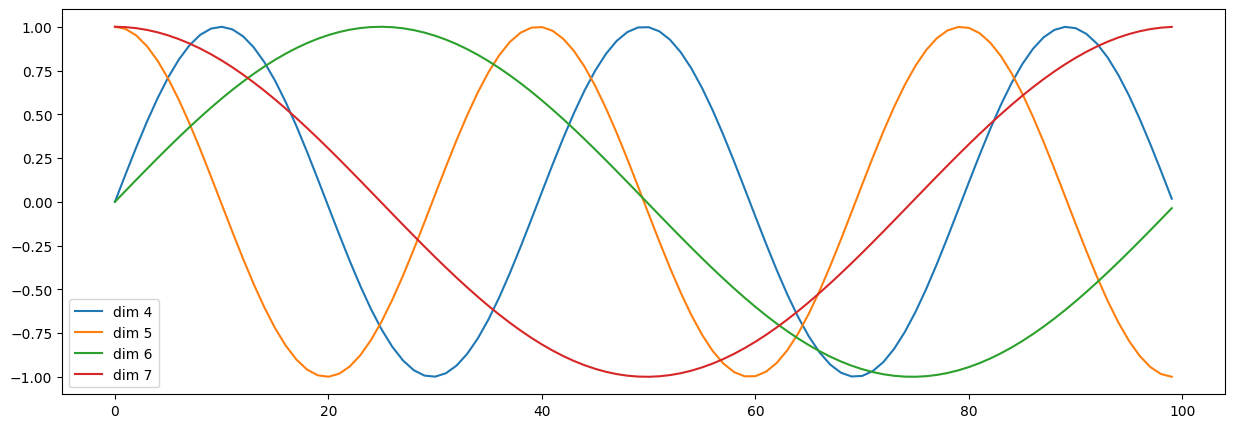

In [23]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 5))
pe = PositionalEncoding(20, 0)
y = pe.forward((torch.zeros(1, 100, 20)))
plt.plot(np.arange(100), y[0, :, 4:8].data.numpy())
plt.legend(["dim %d"%p for p in [4,5,6,7]])

### <font size='4' color='red'>Task 2.6: Implement a Transformer-based Text Classifier (6 points)</font>

In [24]:
class TransformerClassifier(nn.Module):
    """
    A Transformer-based text classifier.
    """
    def __init__(self,
            vocab_size: int, embed_dim: int, num_heads: int, trx_ff_dim: int,
            num_trx_cells: int, num_class: int, dropout: float=0.1, pad_token: int=0
        ):
        """
        Inputs:
        - vocab_size: Vocabulary size, indicating how many tokens we have in total.
        - embed_dim: The dimension of word embeddings
        - num_heads: Number of attention heads in a multi-head attention module
        - trx_ff_dim: The hidden dimension for a feedforward network
        - num_trx_cells: Number of TransformerEncoderCells
        - dropout: Dropout ratio
        - pad_token: The index of the padding token.
        """
        super(TransformerClassifier, self).__init__()

        self.embed_dim = embed_dim
        self.pad_token = pad_token

        # word embedding layer
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_token)

        ###########################################################################
        # TODO: Define a module for positional encoding, Transformer encoder, and #
        # a output layer                                                          #
        ###########################################################################
        
        self.pos_encoding = PositionalEncoding(embed_dim)
        self.encoder = TransformerEncoder(embed_dim, num_heads, trx_ff_dim, num_trx_cells, dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(embed_dim, num_class)
        
        ###########################################################################
        #                             END OF YOUR CODE                            #
        ###########################################################################

    def forward(self, text, mask=None):
        """
        Inputs:
        - text: Tensor with the shape of BxL, containing the indexes of each word in
          the vocabulary, which will be converted into word embeddings with the shape
          of BxLxC
        - mask: Tensor for masking in the multi-head attention

        Return:
        - logits: Tensor with the shape of BxK, where K is the number of classes
        """

        # word embeddings, note we multiple the embeddings by a factor
        embedded = self.embedding(text) * math.sqrt(self.embed_dim)
        if mask is None:
          mask = (text != self.pad_token).unsqueeze(-2).unsqueeze(1)

        logits = None
        ###########################################################################
        # TODO: Apply positional embedding to the input, which is then fed into   #
        # the encoder. Average pooling is applied then to all the features of all #
        # tokens. Finally, the logits are computed based on the pooled features.  #
        ###########################################################################
        
        embedded = self.pos_encoding(embedded)
        encoded = self.encoder(embedded, mask)       # (BxLxC)
        pooled = encoded.mean(dim=1)                 # (BxC)
        logits = self.fc(self.dropout(pooled))       # (Bxnum_class)
        
        ###########################################################################
        #                             END OF YOUR CODE                            #
        ###########################################################################

        return logits

In [25]:
vocab_size = 10
embed_dim = 16
num_heads = 2
trx_ff_dim = 32
num_trx_cells = 2
num_class = 3

x = torch.arange(vocab_size).view(1, -1)
x = torch.cat((x, x), dim=0)
mask = (x != 0).unsqueeze(-2).unsqueeze(1)
model = TransformerClassifier(vocab_size, embed_dim, num_heads, trx_ff_dim, num_trx_cells, num_class)
print('x: {}, mask: {}'.format(x.shape, mask.shape))
y = model(x, mask)
assert len(y.shape) == 2 and y.shape[0] == x.shape[0] and y.shape[1] == num_class
print(y.shape)

x: torch.Size([2, 10]), mask: torch.Size([2, 1, 1, 10])
torch.Size([2, 3])


### <font size='4' color='red'>Task 2.7: Define the model, loss function, optimizer, and learning rate scheduler. And then tune the hyperparameters to train the model. You need to achieve 89% validation accuracy. (10 points)</font>

In [26]:
assert torch.cuda.is_available()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Hyperparameters
# Let's use a fixed number of epochs
epochs = 3 # epoch
###########################################################################
# TODO: Tune the hyper parameters
###########################################################################

lr = 0.0009
batch_size = 64
word_embed_dim = 64
ff_dim = 128
num_heads = 8
num_trx_cells = 4

###########################################################################
#                             END OF YOUR CODE                            #
###########################################################################

train_iter = load_ag_news(split='train')
num_class = len(set([label for (label, text) in train_iter]))
vocab_size = len(vocab)

gradient_norm_clip = 10

###########################################################################
# Define a Transformer-based text classifier, a loss function, optimizer, #
# and learning rate scheduler.                                            #
###########################################################################

model = TransformerClassifier(
    vocab_size, word_embed_dim, num_heads, ff_dim,
    num_trx_cells, num_class, dropout=0.1, pad_token=PAD_TOKEN
)
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.1)

###########################################################################
#                             END OF YOUR CODE                            #
###########################################################################
model = model.to(device)

num_params = sum(p.numel() for p in model.parameters())
print('Number of parameters: {:.3f}K'.format(num_params / 1000))

num_params = sum(p.numel() for p in model.embedding.parameters())
print('Number of parameters: {:.3f}K'.format(num_params / 1000))

# splits have been created in the RNN part
train_dataloader = DataLoader(
    split_train, batch_size=batch_size,
    shuffle=True, collate_fn=collate_batch
)

valid_dataloader = DataLoader(
    split_valid, batch_size=batch_size,
    shuffle=False, collate_fn=collate_batch
)

test_dataloader = DataLoader(
    test_dataset, batch_size=batch_size,
    shuffle=False, collate_fn=collate_batch
)

total_accu = None

# You should be able to get a validation accuracy around 89%
for epoch in range(1, epochs + 1):
    epoch_start_time = time.time()
    train(model, train_dataloader, loss_func, device, gradient_norm_clip)
    accu_val = evaluate(model, valid_dataloader, loss_func, device)
    scheduler.step()
    print('-' * 59)
    print('| end of epoch {:3d} | time: {:5.2f}s | '
          'valid accuracy {:8.3f} '.format(epoch,
                                           time.time() - epoch_start_time,
                                           accu_val))
    print('-' * 59)

cuda
Number of parameters: 6266.180K
Number of parameters: 6131.904K
| epoch   1 |   500/ 1782 batches | accuracy    0.724
| epoch   1 |  1000/ 1782 batches | accuracy    0.834
| epoch   1 |  1500/ 1782 batches | accuracy    0.859
-----------------------------------------------------------
| end of epoch   1 | time: 25.72s | valid accuracy    0.867 
-----------------------------------------------------------
| epoch   2 |   500/ 1782 batches | accuracy    0.901
| epoch   2 |  1000/ 1782 batches | accuracy    0.904
| epoch   2 |  1500/ 1782 batches | accuracy    0.904
-----------------------------------------------------------
| end of epoch   2 | time: 25.59s | valid accuracy    0.889 
-----------------------------------------------------------
| epoch   3 |   500/ 1782 batches | accuracy    0.914
| epoch   3 |  1000/ 1782 batches | accuracy    0.919
| epoch   3 |  1500/ 1782 batches | accuracy    0.916
-----------------------------------------------------------
| end of epoch   3 | ti

## <font color='red'> Part 3: Extra Credits: Image Classification with Transformer (20 points)

### <font size='4' color='red'>Implement VisionTransformer for Image Classification. Train it on the CIFAR10 dataset (you may find the helper functions used in the previous programming assignment helpful. To get the full credits, you need to achieve 50% validation accuracy. Note the following comments and constraints:
- You need to implement a variant of pre-norm Transformer cell shown in Fig. 1 of https://arxiv.org/pdf/2010.11929 (post-norm does not work well here)
- The number of parameters should be smaller than 3.2M.
- No pre-trained weights are allowed.
- Training has to finish within 3 epochs.

Put your full implementation below.
</font>

In [27]:
# As usual, a bit of setup
import time
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading external modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

In [28]:
# let's download the data
# !mkdir ../datasets
# !cd ../datasets

# 1 -- Linux
# 2 -- MacOS
# 3 -- Command Prompt on Windows
# 4 -- manually downloading the data
choice = 1


if choice == 1:
    # should work well on Linux and in Powershell on Windows
    !wget http://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
elif choice == 2 or choice ==3:
    # if wget is not available for you, try curl
    # should work well on MacOS
    !curl http://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz --output cifar-10-python.tar.gz
else:
    print('Please manually download the data from http://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz and put it under the datasets folder.')
!tar -xzvf cifar-10-python.tar.gz

if choice==3:
    !del cifar-10-python.tar.gz
else:
    !rm cifar-10-python.tar.gz

--2026-03-30 16:53:14--  http://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Connecting to 10.99.0.130:3128... connected.
Proxy request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: 'cifar-10-python.tar.gz'

cifar-10-python.tar 100%[===================>] 162.60M  57.5MB/s    in 2.8s    

2026-03-30 16:53:17 (57.5 MB/s) - 'cifar-10-python.tar.gz' saved [170498071/170498071]

cifar-10-batches-py/
cifar-10-batches-py/data_batch_4
cifar-10-batches-py/readme.html
cifar-10-batches-py/test_batch
cifar-10-batches-py/data_batch_3
cifar-10-batches-py/batches.meta
cifar-10-batches-py/data_batch_2
cifar-10-batches-py/data_batch_5
cifar-10-batches-py/data_batch_1


In [29]:
# helpful functions to process and load the data
from six.moves import cPickle as pickle
import numpy as np
import os
import platform

def load_pickle(f):
    version = platform.python_version_tuple()
    if version[0] == '2':
        return  pickle.load(f)
    elif version[0] == '3':
        return  pickle.load(f, encoding='latin1')
    raise ValueError("invalid python version: {}".format(version))

def load_CIFAR_batch(filename):
  """ load single batch of cifar """
  with open(filename, 'rb') as f:
    datadict = load_pickle(f)
    X = datadict['data']
    Y = datadict['labels']
    X = X.reshape(10000, 3, 32, 32).transpose(0,2,3,1).astype("float")
    Y = np.array(Y)
    return X, Y

def load_CIFAR10(ROOT):
  """ load all of cifar """
  xs = []
  ys = []
  for b in range(1,6):
    f = os.path.join(ROOT, 'data_batch_%d' % (b, ))
    X, Y = load_CIFAR_batch(f)
    xs.append(X)
    ys.append(Y)
  Xtr = np.concatenate(xs)
  Ytr = np.concatenate(ys)
  del X, Y
  Xte, Yte = load_CIFAR_batch(os.path.join(ROOT, 'test_batch'))
  return Xtr, Ytr, Xte, Yte


def get_CIFAR10_data(cifar10_dir, num_training=49000, num_validation=1000, num_test=1000,
                     subtract_mean=True):
    """
    Load the CIFAR-10 dataset from disk and perform preprocessing to prepare
    it for classifiers. These are the same steps as we used for the SVM, but
    condensed to a single function.
    """
    # Load the raw CIFAR-10 data
    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

    # Subsample the data
    mask = list(range(num_training, num_training + num_validation))
    X_val = X_train[mask]
    y_val = y_train[mask]
    mask = list(range(num_training))
    X_train = X_train[mask]
    y_train = y_train[mask]
    mask = list(range(num_test))
    X_test = X_test[mask]
    y_test = y_test[mask]

    # Normalize the data: subtract the mean image
    if subtract_mean:
      mean_image = np.mean(X_train, axis=0)
      X_train -= mean_image
      X_val -= mean_image
      X_test -= mean_image

    # Transpose so that channels come first
    X_train = X_train.transpose(0, 3, 1, 2).copy()
    X_val = X_val.transpose(0, 3, 1, 2).copy()
    X_test = X_test.transpose(0, 3, 1, 2).copy()

    # Package data into a dictionary
    return {
      'X_train': X_train, 'y_train': y_train,
      'X_val': X_val, 'y_val': y_val,
      'X_test': X_test, 'y_test': y_test,
    }

In [30]:
# Load the (preprocessed) CIFAR10 data.
cifar10_dir = './cifar-10-batches-py'

data = get_CIFAR10_data(cifar10_dir, subtract_mean=True)

pix_mean = (0.485, 0.456, 0.406)
pix_std = (0.229, 0.224, 0.225)

for c in range(3):
    data['X_train'][:, c] = (data['X_train'][:, c] / 255 - pix_mean[c]) / pix_std[c]
    data['X_val'][:, c] = (data['X_val'][:, c] / 255 - pix_mean[c]) / pix_std[c]
    data['X_test'][:, c] = (data['X_test'][:, c] / 255 - pix_mean[c]) / pix_std[c]

for split in ['train', 'val', 'test']:
    print('===\nFor the split {}'.format(split))
    print('shape: {}'.format(data['X_{}'.format(split)].shape))
    print('data value range, min: {}, max: {}\n'.format(data['X_{}'.format(split)].min(), data['X_{}'.format(split)].max()))

===
For the split train
shape: (49000, 3, 32, 32)
data value range, min: -4.489820571085577, max: 0.8966644435551998

===
For the split val
shape: (1000, 3, 32, 32)
data value range, min: -4.489820571085577, max: 0.8966644435551998

===
For the split test
shape: (1000, 3, 32, 32)
data value range, min: -4.489820571085577, max: 0.8966644435551998



In [31]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=192):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)                   # (B, embed_dim, H/P, W/P)
        x = x.flatten(2).transpose(1, 2)  # (B, num_patches, embed_dim)
        return x

In [32]:
class ViTEncoderCell(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.norm1    = nn.LayerNorm(embed_dim)
        self.attn     = MultiHeadAttention(embed_dim, num_heads)
        self.dropout1 = nn.Dropout(dropout)
        self.norm2    = nn.LayerNorm(embed_dim)
        self.ffn      = FeedForwardNetwork(embed_dim, ff_dim, dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        normed = self.norm1(x)
        x = x + self.dropout1(self.attn(normed, normed, normed))
        x = x + self.dropout2(self.ffn(self.norm2(x)))
        return x

In [33]:
class VisionTransformer(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, num_class=10,
                 embed_dim=128, num_heads=4, ff_dim=128, num_layers=6, dropout=0.1):
        super().__init__()
        num_patches = (img_size // patch_size) ** 2

        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed   = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.dropout     = nn.Dropout(dropout)

        self.layers = nn.ModuleList([
            ViTEncoderCell(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.fc   = nn.Linear(embed_dim, num_class)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        b = x.shape[0]
        x   = self.patch_embed(x)
        cls = self.cls_token.expand(b, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = self.dropout(x + self.pos_embed)
        for layer in self.layers:
            x = layer(x)
        x = self.norm(x[:, 0])   # CLS token
        return self.fc(x)


In [34]:
class CIFARDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        img, label = self.X[idx], self.y[idx]
        if self.augment:
            if torch.rand(1) > 0.5:
                img = torch.flip(img, dims=[2])
            pad = 4
            padded = torch.nn.functional.pad(img, (pad, pad, pad, pad), mode='reflect')
            i = torch.randint(0, 2 * pad, (1,)).item()
            j = torch.randint(0, 2 * pad, (1,)).item()
            img = padded[:, i:i+32, j:j+32]
        return label, img

In [36]:
epochs     = 3
batch_size = 64
lr         = 1e-3

train_dataloader = DataLoader(
    CIFARDataset(data['X_train'], data['y_train'], augment=True),
    batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True
)
valid_dataloader = DataLoader(
    CIFARDataset(data['X_val'], data['y_val'], augment=False),
    batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True
)
test_dataloader = DataLoader(
    CIFARDataset(data['X_test'], data['y_test'], augment=False),
    batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True
)

model = VisionTransformer(
    img_size=32, patch_size=4, in_channels=3, num_class=10,
    embed_dim=128, num_heads=4, ff_dim=128, num_layers=6, dropout=0.1
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print('Number of parameters: {:.3f}M'.format(num_params / 1e6))
assert num_params < 3_200_000, 'Too many parameters: {}'.format(num_params)

loss_func = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.1)

total_accu = None
for epoch in range(1, epochs + 1):
    epoch_start_time = time.time()
    train(model, train_dataloader, loss_func, device, 1.0)
    accu_val = evaluate(model, valid_dataloader, loss_func, device)
    scheduler.step()
    print('-' * 59)
    print('| end of epoch {:3d} | time: {:5.2f}s | '          'valid accuracy {:8.3f} '.format(epoch, time.time() - epoch_start_time,
                                            accu_val))
    print('-' * 59)

Number of parameters: 0.614M
| epoch   1 |   500/  766 batches | accuracy    0.288
-----------------------------------------------------------
| end of epoch   1 | time: 11.79s | valid accuracy    0.425 
-----------------------------------------------------------
| epoch   2 |   500/  766 batches | accuracy    0.459
-----------------------------------------------------------
| end of epoch   2 | time: 11.73s | valid accuracy    0.500 
-----------------------------------------------------------
| epoch   3 |   500/  766 batches | accuracy    0.493
-----------------------------------------------------------
| end of epoch   3 | time: 11.82s | valid accuracy    0.507 
-----------------------------------------------------------
